In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load the dataset
all_available = pd.read_csv(r'D:\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')

# Prepare the feature set and target variables
X = all_available[['Time', 'Lat', 'Lon', 'Ozone', 'Average_Ozone_t-1']]
y = all_available[['PM2.5', 'NO2']]  # Target variables: NO2 and Ozone

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Linear Regression model
mlr = LinearRegression()

# Prepare lists to store scores for each fold for both targets
mse_scores_no2 = []
mae_scores_no2 = []
r2_scores_no2 = []
mape_scores_no2 = []
nrmse_scores_no2 = []

mse_scores_o3 = []
mae_scores_o3 = []
r2_scores_o3 = []
mape_scores_o3 = []
nrmse_scores_o3 = []

# Perform cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    mlr.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = mlr.predict(X_test)

    # Split predictions back into NO2 and Ozone
    y_pred_no2 = y_pred[:, 0]
    y_pred_o3 = y_pred[:, 1]

    # Calculate evaluation metrics for NO2
    mse_scores_no2.append(mean_squared_error(y_test['PM2.5'], y_pred_no2))
    mae_scores_no2.append(mean_absolute_error(y_test['PM2.5'], y_pred_no2))
    r2_scores_no2.append(r2_score(y_test['PM2.5'], y_pred_no2))
    mape_scores_no2.append(np.mean(np.abs((y_test['PM2.5'] - y_pred_no2) / y_test['PM2.5'])) * 100)
    nrmse_scores_no2.append(np.sqrt(mean_squared_error(y_test['PM2.5'], y_pred_no2)) / (y_test['PM2.5'].max() - y_test['PM2.5'].min()))

    # Calculate evaluation metrics for Ozone
    mse_scores_o3.append(mean_squared_error(y_test['NO2'], y_pred_o3))
    mae_scores_o3.append(mean_absolute_error(y_test['NO2'], y_pred_o3))
    r2_scores_o3.append(r2_score(y_test['NO2'], y_pred_o3))
    mape_scores_o3.append(np.mean(np.abs((y_test['NO2'] - y_pred_o3) / y_test['NO2'])) * 100)
    nrmse_scores_o3.append(np.sqrt(mean_squared_error(y_test['NO2'], y_pred_o3)) / (y_test['NO2'].max() - y_test['NO2'].min()))

# Calculate mean and standard deviation for each metric for NO2
mean_mse_no2 = np.mean(mse_scores_no2)
std_mse_no2 = np.std(mse_scores_no2)
mean_mae_no2 = np.mean(mae_scores_no2)
std_mae_no2 = np.std(mae_scores_no2)
mean_r2_no2 = np.mean(r2_scores_no2)
std_r2_no2 = np.std(r2_scores_no2)
mean_mape_no2 = np.mean(mape_scores_no2)
std_mape_no2 = np.std(mape_scores_no2)
mean_nrmse_no2 = np.mean(nrmse_scores_no2)
std_nrmse_no2 = np.std(nrmse_scores_no2)

# Calculate mean and standard deviation for each metric for Ozone
mean_mse_o3 = np.mean(mse_scores_o3)
std_mse_o3 = np.std(mse_scores_o3)
mean_mae_o3 = np.mean(mae_scores_o3)
std_mae_o3 = np.std(mae_scores_o3)
mean_r2_o3 = np.mean(r2_scores_o3)
std_r2_o3 = np.std(r2_scores_o3)
mean_mape_o3 = np.mean(mape_scores_o3)
std_mape_o3 = np.std(mape_scores_o3)
mean_nrmse_o3 = np.mean(nrmse_scores_o3)
std_nrmse_o3 = np.std(nrmse_scores_o3)

# Print evaluation metrics for NO2
print(f"NO2 - Mean Squared Error: {round(mean_mse_no2, 2)} ± {round(std_mse_no2, 2)}")
print(f"NO2 - Mean Absolute Error: {round(mean_mae_no2, 2)} ± {round(std_mae_no2, 2)}")
print(f"NO2 - R^2 Score: {round(mean_r2_no2, 2)} ± {round(std_r2_no2, 2)}")
print(f"NO2 - Mean Absolute Percentage Error: {round(mean_mape_no2, 2)}% ± {round(std_mape_no2, 2)}%")
print(f"NO2 - Normalized RMSE: {round(mean_nrmse_no2, 4)} ± {round(std_nrmse_no2, 4)}")

# Print evaluation metrics for Ozone
print(f"Ozone - Mean Squared Error: {round(mean_mse_o3, 2)} ± {round(std_mse_o3, 2)}")
print(f"Ozone - Mean Absolute Error: {round(mean_mae_o3, 2)} ± {round(std_mae_o3, 2)}")
print(f"Ozone - R^2 Score: {round(mean_r2_o3, 2)} ± {round(std_r2_o3, 2)}")
print(f"Ozone - Mean Absolute Percentage Error: {round(mean_mape_o3, 2)}% ± {round(std_mape_o3, 2)}%")
print(f"Ozone - Normalized RMSE: {round(mean_nrmse_o3, 4)} ± {round(std_nrmse_o3, 4)}")

# Save the model
mlr_output_path = r'D:\Manoj_Honors\mlr_model_NO2_Ozone.joblib'
joblib.dump(mlr, mlr_output_path)
print(f"MLR Model saved to {mlr_output_path}")



C:\Users\Faculty\AppData\Local\Temp\ipykernel_248400\452945702.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


NO2 - Mean Squared Error: 7777.38 ± 71.75
NO2 - Mean Absolute Error: 65.01 ± 0.17
NO2 - R^2 Score: 0.04 ± 0.0
NO2 - Mean Absolute Percentage Error: 226.86% ± 9.16%
NO2 - Normalized RMSE: 0.0884 ± 0.0004
Ozone - Mean Squared Error: 1134.56 ± 17.09
Ozone - Mean Absolute Error: 22.44 ± 0.05
Ozone - R^2 Score: 0.09 ± 0.0
Ozone - Mean Absolute Percentage Error: 233.35% ± 11.74%
Ozone - Normalized RMSE: 0.0675 ± 0.0005
MLR Model saved to D:\Manoj_Honors\mlr_model_NO2_Ozone.joblib


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

# Load the dataset
all_available = pd.read_csv(r'D:\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')

# Prepare the feature set and target variables
X = all_available[['Time', 'Lat', 'Lon', 'Ozone', 'Average_Ozone_t-1']]
y = all_available[['PM2.5', 'NO2']]  # Target variables: NO2 and Ozone

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the XGBoost model
xgb = XGBRegressor(n_estimators=100, random_state=12, objective='reg:squarederror')

# Prepare lists to store scores for each fold for both targets
mse_scores_no2 = []
mae_scores_no2 = []
r2_scores_no2 = []
mape_scores_no2 = []
nrmse_scores_no2 = []

mse_scores_o3 = []
mae_scores_o3 = []
r2_scores_o3 = []
mape_scores_o3 = []
nrmse_scores_o3 = []

# Perform cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xgb.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xgb.predict(X_test)

    # Split predictions back into NO2 and Ozone
    y_pred_no2 = y_pred[:, 0]
    y_pred_o3 = y_pred[:, 1]

    # Calculate evaluation metrics for NO2
    mse_scores_no2.append(mean_squared_error(y_test['PM2.5'], y_pred_no2))
    mae_scores_no2.append(mean_absolute_error(y_test['PM2.5'], y_pred_no2))
    r2_scores_no2.append(r2_score(y_test['PM2.5'], y_pred_no2))
    mape_scores_no2.append(np.mean(np.abs((y_test['PM2.5'] - y_pred_no2) / y_test['PM2.5'])) * 100)
    nrmse_scores_no2.append(np.sqrt(mean_squared_error(y_test['PM2.5'], y_pred_no2)) / (y_test['PM2.5'].max() - y_test['PM2.5'].min()))

    # Calculate evaluation metrics for Ozone
    mse_scores_o3.append(mean_squared_error(y_test['NO2'], y_pred_o3))
    mae_scores_o3.append(mean_absolute_error(y_test['NO2'], y_pred_o3))
    r2_scores_o3.append(r2_score(y_test['NO2'], y_pred_o3))
    mape_scores_o3.append(np.mean(np.abs((y_test['NO2'] - y_pred_o3) / y_test['NO2'])) * 100)
    nrmse_scores_o3.append(np.sqrt(mean_squared_error(y_test['NO2'], y_pred_o3)) / (y_test['NO2'].max() - y_test['NO2'].min()))

# Calculate and print mean and standard deviation for metrics for NO2
print("NO2 Metrics:")
print(f"Mean MSE: {np.mean(mse_scores_no2):.2f} ± {np.std(mse_scores_no2):.2f}")
print(f"Mean MAE: {np.mean(mae_scores_no2):.2f} ± {np.std(mae_scores_no2):.2f}")
print(f"Mean R²: {np.mean(r2_scores_no2):.2f} ± {np.std(r2_scores_no2):.2f}")
print(f"Mean MAPE: {np.mean(mape_scores_no2):.2f}% ± {np.std(mape_scores_no2):.2f}%")
print(f"Mean NRMSE: {np.mean(nrmse_scores_no2):.4f} ± {np.std(nrmse_scores_no2):.4f}")

# Calculate and print mean and standard deviation for metrics for Ozone
print("\nOzone Metrics:")
print(f"Mean MSE: {np.mean(mse_scores_o3):.2f} ± {np.std(mse_scores_o3):.2f}")
print(f"Mean MAE: {np.mean(mae_scores_o3):.2f} ± {np.std(mae_scores_o3):.2f}")
print(f"Mean R²: {np.mean(r2_scores_o3):.2f} ± {np.std(r2_scores_o3):.2f}")
print(f"Mean MAPE: {np.mean(mape_scores_o3):.2f}% ± {np.std(mape_scores_o3):.2f}%")
print(f"Mean NRMSE: {np.mean(nrmse_scores_o3):.4f} ± {np.std(nrmse_scores_o3):.4f}")

# Save the model
xgb_output_path = r'D:\Manoj_Honors\xgboost_model_NO2_Ozone.joblib'
joblib.dump(xgb, xgb_output_path)
print(f"\nXGBoost Model saved to {xgb_output_path}")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_248400\174762193.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


NO2 Metrics:
Mean MSE: 2454.67 ± 47.10
Mean MAE: 31.78 ± 0.16
Mean R²: 0.70 ± 0.00
Mean MAPE: 82.27% ± 2.40%
Mean NRMSE: 0.0497 ± 0.0005

Ozone Metrics:
Mean MSE: 397.97 ± 10.59
Mean MAE: 11.88 ± 0.07
Mean R²: 0.68 ± 0.00
Mean MAPE: 94.58% ± 4.10%
Mean NRMSE: 0.0400 ± 0.0005

XGBoost Model saved to D:\Manoj_Honors\xgboost_model_NO2_Ozone.joblib


Epoch 1/100


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14273/14273 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.1994 - mae: 0.2627 - r2_keras: -35.3250 - val_loss: 0.0030 - val_mae: 0.0351 - val_r2_keras: 0.0505 - learning_rate: 1.0000e-04
Epoch 2/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.0029 - mae: 0.0352 - r2_keras: 0.5045 - val_loss: 0.0025 - val_mae: 0.0321 - val_r2_keras: 0.1954 - learning_rate: 1.0000e-04
Epoch 3/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.0024 - mae: 0.0314 - r2_keras: 0.5848 - val_loss: 0.0024 - val_mae: 0.0310 - val_r2_keras: 0.2387 - learning_rate: 1.0000e-04
Epoch 4/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.0023 - mae: 0.0302 - r2_keras: 0.6106 - val_loss: 0.0023 - val_mae: 0.0308 - val_r2_keras: 0.2434 - learning_rate: 1.0000e-04
Epoch 5/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - loss: 0.0022 - mae: 0.0296 - r2_keras: 0.6245 - val_loss: 0.0023 - val_mae: 0.0300 - val_r2_keras: 0.2594 - learning_rate: 1.0000e-04
Epoch 6/100
14273/14273 ━━━━━━━━━━━━━━━━

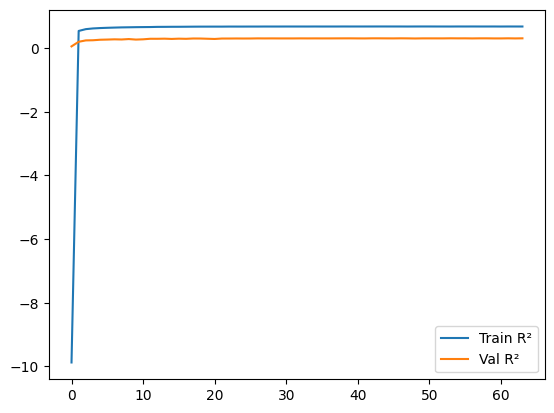

Model saved as 'pollutant_forecasting_model_mlp_optimized.keras'.
Model loaded successfully.


In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop Null values first!
data = data.dropna()

# Drop 'Unnamed: 0' as it's just an index
data_dropped = data.drop(columns=['Unnamed: 0'])

# Convert 'Time' to datetime format and extract useful time features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop the 'Time', 'Lat', and 'Lon' columns
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon'])

# Separate input features and target features
input_features = data_dropped.drop(columns=['NO2', 'PM2.5', 'Ozone'])
target_features = data_dropped[['NO2', 'PM2.5', 'Ozone']]

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -3:]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Build the MLP model
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1] * X_train.shape[2]),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    
    Dense(3)  # Predicting 3 outputs (NO2, PM2.5, Ozone)
])

# Compile the model
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', r2_keras])

# Callbacks for regularization
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Flatten input data for MLP model
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# Train the model
history = model.fit(
    X_train_flat, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_flat, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate the model
y_pred = model.predict(X_val_flat)

# Rescale predictions and true values to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Function to calculate metrics for each pollutant
def calculate_metrics(y_true, y_pred, pollutant_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Metrics for {pollutant_name}:")
    print(f"MSE: {mse:.9f}")
    print(f"MAE: {mae:.9f}")
    print(f"RMSE: {rmse:.9f}")
    print(f"R²: {r2:.9f}")
    print(f"MAPE: {mape:.9f}%")
    print("-" * 40)

# Split the predictions and actual values for each pollutant
y_pred_rescaled_NO2 = y_pred_rescaled[:, 0]
y_val_rescaled_NO2 = y_val_rescaled[:, 0]

y_pred_rescaled_PM25 = y_pred_rescaled[:, 1]
y_val_rescaled_PM25 = y_val_rescaled[:, 1]

y_pred_rescaled_Ozone = y_pred_rescaled[:, 2]
y_val_rescaled_Ozone = y_val_rescaled[:, 2]

# Calculate metrics for each pollutant
calculate_metrics(y_val_rescaled_NO2, y_pred_rescaled_NO2, "NO2")
calculate_metrics(y_val_rescaled_PM25, y_pred_rescaled_PM25, "PM2.5")
calculate_metrics(y_val_rescaled_Ozone, y_pred_rescaled_Ozone, "Ozone")

# Plot training and validation R²
plt.plot(history.history['r2_keras'], label='Train R²')
plt.plot(history.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the model
model.save('pollutant_forecasting_model_mlp_optimized.keras')
print("Model saved as 'pollutant_forecasting_model_mlp_optimized.keras'.")

# Load the model to verify
loaded_model = load_model('pollutant_forecasting_model_mlp_optimized.keras', custom_objects={'r2_keras': r2_keras})
print("Model loaded successfully.")


In [1]:
! pip install geopandas

  Using cached pyproj-3.7.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
   ----- ---------------------------------- 2.1/16.2 MB 11.8 MB/s eta 0:00:02
   ---------- ----------------------------- 4.2/16.2 MB 11.5 MB/s eta 0:00:02
   ---------------- ----------------------- 6.6/16.2 MB 11.2 MB/s eta 0:00:01
   ---------------------- ----------------- 8.9/16.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------- ----------- 11.5/16.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------------- ----- 13.9/16.2 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------  16.0/16.2 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 16.2/16.2 MB 10.8 MB/s eta 0:00:00
Using cached pyproj-3.7.0-cp312-cp312-win_amd64.whl (6.2 MB)


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load the dataset
file_path = r"D:\Manoj_Honors\Merged_Data.csv"  # Replace with your file path
data = pd.read_csv(file_path)

# Convert the dataset into a GeoDataFrame
data['geometry'] = data.apply(lambda row: Point(row['Lon'], row['Lat']), axis=1)
stations_gdf = gpd.GeoDataFrame(data, geometry='geometry', crs="EPSG:4326")

# Identify observed NO2 data
observed_no2 = stations_gdf[stations_gdf['NO2'].notnull()]

# Split the observed data into training and validation sets
validation_fraction = 0.2  # Fraction of observed data to be used for validation
validation_set = observed_no2.sample(frac=validation_fraction, random_state=42)
training_set = observed_no2.drop(validation_set.index)

# IDW Interpolation Function
def idw_interpolation(training_gdf, values, target_gdf, power=2):
    # Extract coordinates
    training_coords = np.array(list(zip(training_gdf.geometry.x, training_gdf.geometry.y)))
    target_coords = np.array(list(zip(target_gdf.geometry.x, target_gdf.geometry.y)))

    # Create a KDTree for fast spatial searching
    tree = cKDTree(training_coords)

    # Interpolate
    interpolated_values = []
    for coord in target_coords:
        dists, idxs = tree.query(coord, k=len(training_coords), p=2)
        weights = 1 / (dists ** power)
        weighted_values = values[idxs] * weights
        interpolated_values.append(np.sum(weighted_values) / np.sum(weights))

    return np.array(interpolated_values)

# Interpolate for the validation set
training_coords = training_set.geometry
training_values = training_set['NO2'].values
validation_coords = validation_set.geometry

interpolated_values = idw_interpolation(training_set, training_values, validation_set)

# Actual and predicted NO2 values
actual_values = validation_set['NO2'].values
predicted_values = interpolated_values

# Evaluation metrics
r2 = r2_score(actual_values, predicted_values)
mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

# Print evaluation results
print("Evaluation Metrics for IDW Interpolation:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Impute missing NO2 values in the original dataset
missing_no2 = stations_gdf[stations_gdf['NO2'].isnull()]
if not missing_no2.empty:
    interpolated_missing = idw_interpolation(training_set, training_values, missing_no2)
    stations_gdf.loc[stations_gdf['NO2'].isnull(), 'NO2'] = interpolated_missing

# Save the imputed dataset
output_file_path = r"D:\Manoj_Honors\Merged_Data(NO2 Imputed).csv"  # Replace with your desired output path
stations_gdf.drop(columns='geometry').to_csv(output_file_path, index=False)

print(f"Imputed NO2 values saved to {output_file_path}.")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_20172\1537127887.py:37: RuntimeWarning: divide by zero encountered in divide
  weights = 1 / (dists ** power)
C:\Users\Faculty\AppData\Local\Temp\ipykernel_20172\1537127887.py:39: RuntimeWarning: invalid value encountered in scalar divide
  interpolated_values.append(np.sum(weighted_values) / np.sum(weights))


ValueError: Input contains NaN.